<a href="https://colab.research.google.com/github/dfreyes/m2t2/blob/main/m2t2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Taller: Adquisición, procesamiento y visualización de datos

---

###Objetivos del Proyecto
*   Aprender a manipular datos en varios formatos y con varias herramientas.
*   Realizar un análisis de datos exploratorio en un set de datos desconocido.
*   Utilizar técnicas de visualización de datos para la exploración.
*   Familiarizarse con librerías y herramientas avanzadas en ciencia de datos.
---

###Fundamentos de ciencia de datos
Modulo 2 Taller 1
|   |   |
| :--- | :--- |
| **Autor:** | Ing. Diego F. Reyes Y. |
| **Fecha:** | Septiembre 2026 |
| **Fuente de Datos:** | https://archive.ics.uci.edu/dataset/352/online+retail *(Online Retail Data Set)* |
---

# Parte 1: Adquisición y limpieza de datos

*   Implementar un script que lea el archivo de datos
*   Realizar la limpieza de los datos explicando la lógica de cada decisión
*   Subir los datos limpios a una base de datos SQLite
---


In [126]:
import pandas as pd

In [127]:
# Adquision de datos
print(" • " * 20)
print(" Recuerde cargar el set de datos antes de usar el codigo ")
print(" El nombre es OnlineRetail.xlsx ")
print(" • " * 20)

 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
 Recuerde cargar el set de datos antes de usar el codigo 
 El nombre es OnlineRetail.xlsx 
 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 


In [128]:
print(" • " * 20)
print(f"\033[1mLectura del archivo de datos a traves de la importacion de la libreria\033[0m")
# Lee el archivo Excel
df = pd.read_excel('OnlineRetail.xlsx')
# Muestra las primeras 5 filas para verificar el contenido
df.head()


 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
Lectura del archivo de datos a traves de la importacion de la libreria


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [129]:
# Limpieza de los datos
print(" • " * 20)
print(f"\033[1mLimpieza de datos\033[0m")
df.info()

 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
Limpieza de datos
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB



| Variable Name | Role | Type | Description | Units | Missing Values |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **InvoiceNo** | ID | Categorical | a 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c', it indicates a cancellation | | no |
| **StockCode** | ID | Categorical | a 5-digit integral number uniquely assigned to each distinct product | | no |
| **Description** | Feature | Categorical | product name | | no |
| **Quantity** | Feature | Integer | the quantities of each product (item) per transaction | | no |
| **InvoiceDate** | Feature | Date | the day and time when each transaction was generated | | no |
| **UnitPrice** | Feature | Continuous | product price per unit | sterling | no |
| **CustomerID** | Feature | Categorical | a 5-digit integral number uniquely assigned to each customer | | no |
| **Country** | Feature | Categorical | the name of the country where each customer resides | | no |


In [130]:
# Limpieza de los datos
print(" • " * 20)
print(f"\033[1mAnalisis de datos\033[0m")
# Trasnformacion de datos
import numpy as np
# 1. Crear el campo 'InvoiceNo_C': 1 si inicia con 'C' o 'c', de lo contrario 0
df['InvoiceNo_C'] = df['InvoiceNo'].astype(str).str.startswith(('C', 'c')).astype(int)

# 2. Crear el campo 'InvoiceNoN': extraer solo los dígitos numéricos y convertir a entero
# Usamos str.extract para obtener los números y fillna por si acaso hay un valor inesperado
df['InvoiceNoN'] = df['InvoiceNo'].astype(str).str.extract(r'(\d+)').astype('Int64')

#print(df.head)
df.info()


#
print(" • " * 20)
print("\n--- Conteo de Frecuencias de InvoiceNoN ---")
print(f"Total de registros: {df['InvoiceNoN'].count()}")
print(f"Cantidad de facturas únicas: {df['InvoiceNoN'].nunique()}")
#
print(" • " * 20)
print("\n--- Conteo de Frecuencias de InvoiceNo_C (Cancelaciones) ---")
print(df['InvoiceNo_C'].value_counts())
print("\nPorcentaje:")
print(df['InvoiceNo_C'].value_counts(normalize=True) * 100)


 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
Analisis de datos
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
 8   InvoiceNo_C  541909 non-null  int64         
 9   InvoiceNoN   541909 non-null  Int64         
dtypes: Int64(1), datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 41.9+ MB
 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 

--- Conteo de Frecuencias de InvoiceNoN ---
Total de reg

In [131]:
# Aseguramos que StockCode sea tratado como texto y limpiamos espacios vacíos
df['StockCode_str'] = df['StockCode'].astype(str).str.strip()

# 1. Regla para puramente numéricos o número + una letra
# Explicación del regex:
# ^(\d+)$ -> Captura si son solo dígitos (va a StockCodeV, AUX1 queda vacío)
# ^(\d+)([a-zA-Z])$ -> Captura dígitos seguidos de exactamente UNA letra (Dígitos a StockCodeV, Letra a AUX1)
regex_patron = r'^(\d+)$|^(\d+)([a-zA-Z])$'

# Extraemos las coincidencias
extraccion = df['StockCode_str'].str.extract(regex_patron)

# Combinamos las columnas extraídas para formar StockCodeV y AUX1
df['StockCodeV'] = extraccion[0].fillna(extraccion[1])
df['AUX1'] = extraccion[2]

# 2. Regla para AUX2: si no cumplió ninguna de las anteriores (ambas quedaron vacías)
# Colocamos el valor original de StockCode, de lo contrario dejamos NaN (o vacío)
df['AUX2'] = np.where(df['StockCodeV'].isna() & df['AUX1'].isna(), df['StockCode_str'], np.nan)

# Opcional: Convertir StockCodeV a entero limpio (Int64) para los que sí son numéricos
df['StockCodeV'] = pd.to_numeric(df['StockCodeV'], errors='coerce').astype('Int64')

# Limpiamos la columna temporal
df.drop(columns=['StockCode_str'], inplace=True)

# Verificamos una muestra del resultado
print(df[['StockCode', 'StockCodeV', 'AUX1', 'AUX2']].drop_duplicates().head(20))

# Limpieza de los datos
print(" • " * 20)
print(f"\033[1m AUX1 Y AUX2 TIENE VALIDACIONES DE DE CODIGO DE PRODUCTO\033[0m")

   StockCode  StockCodeV AUX1 AUX2
0     85123A       85123    A  NaN
1      71053       71053  NaN  NaN
2     84406B       84406    B  NaN
3     84029G       84029    G  NaN
4     84029E       84029    E  NaN
5      22752       22752  NaN  NaN
6      21730       21730  NaN  NaN
7      22633       22633  NaN  NaN
8      22632       22632  NaN  NaN
9      84879       84879  NaN  NaN
10     22745       22745  NaN  NaN
11     22748       22748  NaN  NaN
12     22749       22749  NaN  NaN
13     22310       22310  NaN  NaN
14     84969       84969  NaN  NaN
15     22623       22623  NaN  NaN
16     22622       22622  NaN  NaN
17     21754       21754  NaN  NaN
18     21755       21755  NaN  NaN
19     21777       21777  NaN  NaN
 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
 AUX1 Y AUX2 TIENE VALIDACIONES DE DE CODIGO DE PRODUCTO


In [132]:
# 1. Creamos el filtro lógico directo
filtro_mas_5 = (df['StockCodeV'].notna()) & (df['StockCodeV'].astype(str).str.len() > 5)

# 2. Contamos el total de filas que cumplen la condición
total_filas = filtro_mas_5.sum()

# 3. Contamos cuántos códigos únicos de producto cumplen la condición
codigos_unicos = df.loc[filtro_mas_5, 'StockCodeV'].nunique()

print(f"Total de registros (filas) con más de 5 dígitos: {total_filas}")
print(f"Cantidad de productos ÚNICOS con más de 5 dígitos: {codigos_unicos}")


Total de registros (filas) con más de 5 dígitos: 0
Cantidad de productos ÚNICOS con más de 5 dígitos: 0


In [133]:
# Limpieza de los datos
print(" • " * 20)
print(f"\033[1mValidacion de descripcion \033[0m")

# 1. Contar la cantidad exacta de valores nulos en la columna Description
total_nulos = df['Description'].isna().sum()

# 2. Calcular el porcentaje que representan sobre el total del dataset
porcentaje_nulos = df['Description'].isna().mean() * 100

print("==================================================================")
print("               ANÁLISIS DE NULOS EN 'Description'                 ")
print("==================================================================")
print(f"Cantidad de registros vacíos (nulos): {total_nulos:,}")
print(f"Porcentaje de valores nulos:         {porcentaje_nulos:.2f}%")
print("==================================================================")


 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
Validacion de descripcion 
               ANÁLISIS DE NULOS EN 'Description'                 
Cantidad de registros vacíos (nulos): 1,454
Porcentaje de valores nulos:         0.27%


In [134]:
# Limpieza de los datos
print(" • " * 20)
print(f"\033[1mValidacion de Quantity \033[0m")

# 1. Contar la cantidad exacta de valores nulos en la columna Description
total_nulos = df['Quantity'].isna().sum()

# 2. Calcular el porcentaje que representan sobre el total del dataset
porcentaje_nulos = df['Quantity'].isna().mean() * 100

print("==================================================================")
print("               ANÁLISIS DE NULOS EN 'Quantity'                 ")
print("==================================================================")
print(f"Cantidad de registros vacíos (nulos): {total_nulos:,}")
print(f"Porcentaje de valores nulos:         {porcentaje_nulos:.2f}%")
print("==================================================================")

 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
Validacion de Quantity 
               ANÁLISIS DE NULOS EN 'Quantity'                 
Cantidad de registros vacíos (nulos): 0
Porcentaje de valores nulos:         0.00%


In [135]:
# 1. Convertir a numérico corrigiendo errores (vuelve NaN cualquier texto extraño)
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

# 2. Rellenar nulos con 0 (en caso de que existieran valores vacíos o corruptos)
df['Quantity'] = df['Quantity'].fillna(0)

# 3. Transformar de forma definitiva a tipo entero puro (int64)
df['Quantity'] = df['Quantity'].astype(int)

# 4. Verificar la transformación y ver estadísticas básicas
print("--- Verificación del Tipo de Dato ---")
print(df['Quantity'].dtypes)


--- Verificación del Tipo de Dato ---
int64


In [136]:
# Limpieza de los datos
print(" • " * 20)
print(f"\033[1mValidacion de InvoiceDate \033[0m")

# 1. Contar la cantidad exacta de valores nulos en la columna Description
total_nulos = df['InvoiceDate'].isna().sum()

# 2. Calcular el porcentaje que representan sobre el total del dataset
porcentaje_nulos = df['InvoiceDate'].isna().mean() * 100

print("==================================================================")
print("               ANÁLISIS DE NULOS EN 'InvoiceDate'                 ")
print("==================================================================")
print(f"Cantidad de registros vacíos (nulos): {total_nulos:,}")
print(f"Porcentaje de valores nulos:         {porcentaje_nulos:.2f}%")
print("==================================================================")

 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
Validacion de InvoiceDate 
               ANÁLISIS DE NULOS EN 'InvoiceDate'                 
Cantidad de registros vacíos (nulos): 0
Porcentaje de valores nulos:         0.00%


In [137]:
import pandas as pd

# 1. Transformar la columna a formato Fecha y Hora (datetime) especificando el formato exacto
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%d/%m/%Y %H:%M', errors='coerce')

# ==============================================================================
# 2. EXTRACCIÓN DE NUEVOS CAMPOS CLAVE PARA ANÁLISIS (Recomendado)
# ==============================================================================

# Extraer el Año-Mes (Ideal para agrupaciones mensuales de ventas)
df['AñoMes'] = df['InvoiceDate'].dt.to_period('M')

# Extraer solo la Fecha (sin la hora, para análisis por día)
df['Fecha'] = df['InvoiceDate'].dt.date

# Extraer la Hora del día (para identificar picos de tráfico de compras)
df['Hora'] = df['InvoiceDate'].dt.hour


# ==============================================================================
# 3. VERIFICACIÓN DEL RESULTADO
# ==============================================================================
print("--- Tipo de dato de la columna original ---")
print(df['InvoiceDate'].dtypes)

print("\n--- Muestra de los nuevos campos de tiempo generados ---")
print(df[['InvoiceDate', 'AñoMes', 'Fecha', 'Hora']].head())


--- Tipo de dato de la columna original ---
datetime64[ns]

--- Muestra de los nuevos campos de tiempo generados ---
          InvoiceDate   AñoMes       Fecha  Hora
0 2010-12-01 08:26:00  2010-12  2010-12-01     8
1 2010-12-01 08:26:00  2010-12  2010-12-01     8
2 2010-12-01 08:26:00  2010-12  2010-12-01     8
3 2010-12-01 08:26:00  2010-12  2010-12-01     8
4 2010-12-01 08:26:00  2010-12  2010-12-01     8


In [138]:
# Limpieza de los datos
print(" • " * 20)
print(f"\033[1mValidacion de Country \033[0m")

# 1. Contar la cantidad exacta de valores nulos en la columna Description
total_nulos = df['Country'].isna().sum()

# 2. Calcular el porcentaje que representan sobre el total del dataset
porcentaje_nulos = df['Country'].isna().mean() * 100

print("==================================================================")
print("               ANÁLISIS DE NULOS EN 'Country'                 ")
print("==================================================================")
print(f"Cantidad de registros vacíos (nulos): {total_nulos:,}")
print(f"Porcentaje de valores nulos:         {porcentaje_nulos:.2f}%")
print("==================================================================")

 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
Validacion de Country 
               ANÁLISIS DE NULOS EN 'Country'                 
Cantidad de registros vacíos (nulos): 0
Porcentaje de valores nulos:         0.00%


In [139]:
# Limpieza de los datos
print(" • " * 20)
print(f"\033[1mValidacion de CustomerID \033[0m")

# 1. Contar la cantidad exacta de valores nulos en la columna Description
total_nulos = df['CustomerID'].isna().sum()

# 2. Calcular el porcentaje que representan sobre el total del dataset
porcentaje_nulos = df['CustomerID'].isna().mean() * 100

print("==================================================================")
print("               ANÁLISIS DE NULOS EN 'CustomerID'                 ")
print("==================================================================")
print(f"Cantidad de registros vacíos (nulos): {total_nulos:,}")
print(f"Porcentaje de valores nulos:         {porcentaje_nulos:.2f}%")
print("==================================================================")

 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
Validacion de CustomerID 
               ANÁLISIS DE NULOS EN 'CustomerID'                 
Cantidad de registros vacíos (nulos): 135,080
Porcentaje de valores nulos:         24.93%


In [140]:
#estructura de los datos
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceNo_C,InvoiceNoN,StockCodeV,AUX1,AUX2,AñoMes,Fecha,Hora
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,0,536365,85123,A,NaN,2010-12,2010-12-01,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,536365,71053,NaN,NaN,2010-12,2010-12-01,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,0,536365,84406,B,NaN,2010-12,2010-12-01,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,536365,84029,G,NaN,2010-12,2010-12-01,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,536365,84029,E,NaN,2010-12,2010-12-01,8


In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 16 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
 8   InvoiceNo_C  541909 non-null  int64         
 9   InvoiceNoN   541909 non-null  Int64         
 10  StockCodeV   538524 non-null  Int64         
 11  AUX1         51488 non-null   object        
 12  AUX2         3385 non-null    object        
 13  AñoMes       541909 non-null  period[M]     
 14  Fecha        541909 non-null  object        
 15  Hora         541909 non-null  int3

In [142]:
import sqlite3
import pandas as pd

# 1. Crear una copia temporal para adaptar los tipos de datos a SQLite
df_exportar = df.copy()

# Convertimos los enteros de Pandas (Int64) a float/estándar si tienen nulos, o a enteros tradicionales
df_exportar['InvoiceNoN'] = df_exportar['InvoiceNoN'].astype(float)
df_exportar['StockCodeV'] = df_exportar['StockCodeV'].astype(float)

# Convertimos el tipo Period[M] (AñoMes) a texto para que SQLite lo guarde limpiamente
df_exportar['AñoMes'] = df_exportar['AñoMes'].astype(str)

# Convertimos el objeto Fecha a texto (string)
df_exportar['Fecha'] = df_exportar['Fecha'].astype(str)


# 2. Establecer la conexión con la base de datos SQLite
# Se creará un archivo llamado 'OnlineRetail.db' en tu misma carpeta de trabajo
conexion = sqlite3.connect('OnlineRetail.db')


# 3. Subir el DataFrame a la base de datos
print("Subiendo 541,909 registros a SQLite... Por favor espera.")

df_exportar.to_sql(
    name='ventas_retail',       # Nombre de la tabla dentro de la base de datos
    con=conexion,               # Tu objeto de conexión
    if_exists='replace',        # Opciones: 'fail' (da error si ya existe), 'replace' (la sobrescribe) o 'append' (añade filas)
    index=False,                # No guarda el índice numérico del DataFrame como columna
    chunksize=50000             # Sube los datos en bloques de 50k filas para optimizar el uso de memoria
)

# 4. Cerrar la conexión de forma segura
conexion.close()

print("==================================================================")
print("¡ÉXITO! Se ha creado 'OnlineRetail.db' y la tabla 'ventas_retail'.")
print("==================================================================")

Subiendo 541,909 registros a SQLite... Por favor espera.
¡ÉXITO! Se ha creado 'OnlineRetail.db' y la tabla 'ventas_retail'.


In [143]:
import sqlite3
import pandas as pd

# 1. Nos conectamos a la base de datos que creamos en el paso anterior
conexion = sqlite3.connect('OnlineRetail.db')

print("==================================================================")
print("             DESCRIPCIÓN DE LA ESTRUCTURA EN SQLITE               ")
print("==================================================================")

# 2. Obtener el esquema de la tabla (Nombres de columnas, tipos de datos y restricciones)
# Usamos PRAGMA table_info, que es el equivalente al .info() o .dtypes de Pandas en SQLite
query_columnas = "PRAGMA table_info(ventas_retail);"
df_columnas = pd.read_sql_query(query_columnas, conexion)

# Renombramos las columnas del resultado para que sea más intuitivo de leer
df_columnas = df_columnas[['cid', 'name', 'type', 'notnull', 'dflt_value']].rename(
    columns={'cid': 'ID', 'name': 'Columna', 'type': 'Tipo_Dato_SQL', 'notnull': 'Obligatorio'}
)
print("--- 1. Columnas y Tipos de Datos en la Base de Datos ---")
print(df_columnas.to_string(index=False))


print("\n==================================================================")
print("--- 2. Limpieza de Datos: Eliminando Precios Negativos ---")

# Creamos un cursor para ejecutar comandos de modificación de datos (DML)
cursor = conexion.cursor()

# Ejecutamos la sentencia para borrar los registros inválidos
cursor.execute("DELETE FROM ventas_retail WHERE UnitPrice < 0;")

# Guardamos los cambios de forma permanente en la base de datos (.db)
conexion.commit()

# Verificamos cuántas filas fueron afectadas/eliminadas
print(f"Registros eliminados con éxito: {cursor.rowcount}")



# 3. Consultar estadísticas de volumen directo en SQL
print("\n==================================================================")
print("--- 2. Conteo de Registros Directo desde SQL ---")
query_conteo = """
SELECT
    COUNT(*) as Total_Filas,
    COUNT(CustomerID) as Clientes_No_Nulos,
    (COUNT(*) - COUNT(CustomerID)) as Clientes_Nulos,
    COUNT(DISTINCT Country) as Paises_Unicos
FROM ventas_retail;
"""
df_conteo = pd.read_sql_query(query_conteo, conexion)
print(df_conteo.to_string(index=False))


# 4. Traer una vista previa rápida (Primeras 5 filas) para verificar que el contenido esté intacto
print("\n==================================================================")
print("--- 3. Vista Previa de los Primeros 5 Registros ---")
query_preview = "SELECT InvoiceNo, StockCode, Quantity, InvoiceDate, UnitPrice, Country FROM ventas_retail LIMIT 5;"
df_preview = pd.read_sql_query(query_preview, conexion)
print(df_preview.to_string(index=False))

# Siempre cerramos la conexión al terminar
conexion.close()


             DESCRIPCIÓN DE LA ESTRUCTURA EN SQLITE               
--- 1. Columnas y Tipos de Datos en la Base de Datos ---
 ID     Columna Tipo_Dato_SQL  Obligatorio dflt_value
  0   InvoiceNo          TEXT            0       None
  1   StockCode          TEXT            0       None
  2 Description          TEXT            0       None
  3    Quantity       INTEGER            0       None
  4 InvoiceDate     TIMESTAMP            0       None
  5   UnitPrice          REAL            0       None
  6  CustomerID          REAL            0       None
  7     Country          TEXT            0       None
  8 InvoiceNo_C       INTEGER            0       None
  9  InvoiceNoN          REAL            0       None
 10  StockCodeV          REAL            0       None
 11        AUX1          TEXT            0       None
 12        AUX2          TEXT            0       None
 13      AñoMes          TEXT            0       None
 14       Fecha          TEXT            0       None
 15        H

---
---
---

# Parte 2: EDA
*   Realizar un análisis y una descripción (incluir como archivo de texto) de que información contiene el set de datos. ¿Qué puede decir o cómo puedes
describir este set de datos?
*   Realizar la lectura de los datos de la base de datos utilizando Python y
transformando la tabla a un dataframe de pandas.
*   Describir lo encontrado para cada uno de los campos
*   ¿Qué meta-data se puede generar?
*   Utilizar la documentación del dataset como referencia


In [144]:
#code
print(" • " * 20)
print(f"""\033[1mSe dispoende un archivo Estructura_SQLite_OnlineRetail.txt donde se presenta
una descripcion de las variables usadas como tambien el tipo de datos \033[0m""")


 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
Se dispoende un archivo Estructura_SQLite_OnlineRetail.txt donde se presenta 
una descripcion de las variables usadas como tambien el tipo de datos 


In [145]:
import sqlite3
import pandas as pd

print(" • " * 20)
print(f"""\033[1mLectura desde SQLITE \033[0m""")

conexion = sqlite3.connect('OnlineRetail.db')

print("==================================================================")
print("             DESCRIPCIÓN DE LA ESTRUCTURA EN SQLITE               ")
print("==================================================================")

# 2. Consultar estadísticas de volumen directo en SQL
print("\n==================================================================")
print("--- 2. Conteo de Registros Directo desde SQL ---")
query_conteo = """
SELECT
    COUNT(*) as Total_Filas,
    COUNT(CustomerID) as Clientes_No_Nulos,
    (COUNT(*) - COUNT(CustomerID)) as Clientes_Nulos,
    COUNT(DISTINCT Country) as Paises_Unicos
FROM ventas_retail;
"""
df_conteo = pd.read_sql_query(query_conteo, conexion)
print(df_conteo.to_string(index=False))

#  Traer una vista previa rápida (Primeras 5 filas) para verificar que el contenido esté intacto
print("\n==================================================================")
print("--- 3. Vista Previa de los Primeros 5 Registros ---")
query_preview = "SELECT InvoiceNo, StockCode, Quantity, InvoiceDate, UnitPrice, Country FROM ventas_retail LIMIT 5;"
df_preview = pd.read_sql_query(query_preview, conexion)
print(df_preview.to_string(index=False))

# Siempre cerramos la conexión al terminar
conexion.close()

 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
Lectura desde SQLITE 
             DESCRIPCIÓN DE LA ESTRUCTURA EN SQLITE               

--- 2. Conteo de Registros Directo desde SQL ---
 Total_Filas  Clientes_No_Nulos  Clientes_Nulos  Paises_Unicos
      541907             406829          135078             38

--- 3. Vista Previa de los Primeros 5 Registros ---
InvoiceNo StockCode  Quantity         InvoiceDate  UnitPrice        Country
   536365    85123A         6 2010-12-01 08:26:00       2.55 United Kingdom
   536365     71053         6 2010-12-01 08:26:00       3.39 United Kingdom
   536365    84406B         8 2010-12-01 08:26:00       2.75 United Kingdom
   536365    84029G         6 2010-12-01 08:26:00       3.39 United Kingdom
   536365    84029E         6 2010-12-01 08:26:00       3.39 United Kingdom


In [146]:

import sqlite3
import pandas as pd

print(" • " * 20)
print(f"""\033[1m Realizar la lectura de los datos de la base de datos utilizando Python y transformando la tabla a un dataframe de pandas \033[0m""")

# 1. Establecer la conexión con la base de datos SQLite
conexion = sqlite3.connect('OnlineRetail.db')

# 2. Definir la consulta SQL para traer todos los campos de tu tabla
query = "SELECT * FROM ventas_retail;"

print("Leyendo los datos desde SQLite hacia Pandas... Por favor espera.")

# 3. Cargar los datos directamente en el nuevo DataFrame 'dfsql'
dfsql = pd.read_sql_query(query, conexion)

# 4. Cerrar la conexión de forma segura
conexion.close()

# ==============================================================================
# 5. VERIFICACIÓN Y AUDITORÍA DEL NUEVO DATAFRAME
# ==============================================================================
print("\n==================================================================")
print("¡LECTURA COMPLETADA CON ÉXITO!")
print("==================================================================")
print(f"Nombre del nuevo DataFrame : 'dfsql'")
print(f"Cantidad total de filas    : {dfsql.shape[0]:,}")
print(f"Cantidad total de columnas : {dfsql.shape[1]}")

print("\n--- Vista previa de las primeras 3 filas de 'dfsql' ---")
print(dfsql.head(3).to_string(index=False))


 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
 Realizar la lectura de los datos de la base de datos utilizando Python y transformando la tabla a un dataframe de pandas 
Leyendo los datos desde SQLite hacia Pandas... Por favor espera.

¡LECTURA COMPLETADA CON ÉXITO!
Nombre del nuevo DataFrame : 'dfsql'
Cantidad total de filas    : 541,907
Cantidad total de columnas : 16

--- Vista previa de las primeras 3 filas de 'dfsql' ---
InvoiceNo StockCode                        Description  Quantity         InvoiceDate  UnitPrice  CustomerID        Country  InvoiceNo_C  InvoiceNoN  StockCodeV AUX1 AUX2  AñoMes      Fecha  Hora
   536365    85123A WHITE HANGING HEART T-LIGHT HOLDER         6 2010-12-01 08:26:00       2.55     17850.0 United Kingdom            0    536365.0     85123.0    A None 2010-12 2010-12-01     8
   536365     71053                WHITE METAL LANTERN         6 2010-12-01 08:26:00       3.39     17850.0 United Kingdom            0    536365.0     71053.0 None N

In [147]:
# Descripcion de la informacion de la transformacion de SQLITE a Dataframe
dfsql.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541907 entries, 0 to 541906
Data columns (total 16 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541907 non-null  object 
 1   StockCode    541907 non-null  object 
 2   Description  540453 non-null  object 
 3   Quantity     541907 non-null  int64  
 4   InvoiceDate  541907 non-null  object 
 5   UnitPrice    541907 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541907 non-null  object 
 8   InvoiceNo_C  541907 non-null  int64  
 9   InvoiceNoN   541907 non-null  float64
 10  StockCodeV   538524 non-null  float64
 11  AUX1         51488 non-null   object 
 12  AUX2         3383 non-null    object 
 13  AñoMes       541907 non-null  object 
 14  Fecha        541907 non-null  object 
 15  Hora         541907 non-null  int64  
dtypes: float64(4), int64(3), object(9)
memory usage: 66.2+ MB


In [148]:
print(" • " * 20)
print(f"""\033[1m Describir lo encontrado para cada uno de los campos \033[0m""")

print(f"""\033[1m InvoiceNo, InvoiceNo_C  y InvoiceNoN  \033[0m""")

# 1. Número de facturas totales existentes (valores únicos en InvoiceNo)
total_facturas = dfsql['InvoiceNo'].nunique()

# 2. Número de facturas canceladas
# Si InvoiceNo_C es un flag binario (1 = Cancelada, 0 = Vigente):
facturas_canceladas = dfsql[dfsql['InvoiceNo_C'] == 1]['InvoiceNo'].nunique()
# NOTA: Si en tu caso se filtra de otra forma (ej. si InvoiceNo empieza con 'C'), cambia la condición.

# 3. Número de facturas vigentes
# Si InvoiceNoN solo tiene registros de facturas válidas/activas:
facturas_vigentes = dfsql[dfsql['InvoiceNoN'].notna() & (dfsql['InvoiceNo_C'] != 1)]['InvoiceNo'].nunique()

# Calcular porcentajes para la relación
porc_canceladas = (facturas_canceladas / total_facturas) * 100 if total_facturas > 0 else 0
porc_vigentes = (facturas_vigentes / total_facturas) * 100 if total_facturas > 0 else 0

# 4. Crear la tabla resumen de relación
tabla_resumen = pd.DataFrame({
    'Métrica / Estado': ['Totales (Existentes)', 'Canceladas', 'Vigentes'],
    'Columna Utilizada': ['InvoiceNo', 'InvoiceNo_C', 'InvoiceNoN'],
    'Cantidad Facturas Únicas': [total_facturas, facturas_canceladas, facturas_vigentes],
    'Porcentaje (%)': [100.0, porc_canceladas, porc_vigentes]
})

# Mostrar resultados
print("--- Métricas de Facturación ---")
print(f"Facturas Existentes (InvoiceNo): {total_facturas}")
print(f"Facturas Canceladas (InvoiceNo_C): {facturas_canceladas}")
print(f"Facturas Vigentes (InvoiceNoN): {facturas_vigentes}\n")
print("--- Tabla Resumen de Relación ---")
print(tabla_resumen.to_string(index=False))



 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
 Describir lo encontrado para cada uno de los campos 
 InvoiceNo, InvoiceNo_C  y InvoiceNoN  
--- Métricas de Facturación ---
Facturas Existentes (InvoiceNo): 25898
Facturas Canceladas (InvoiceNo_C): 3836
Facturas Vigentes (InvoiceNoN): 22062

--- Tabla Resumen de Relación ---
    Métrica / Estado Columna Utilizada  Cantidad Facturas Únicas  Porcentaje (%)
Totales (Existentes)         InvoiceNo                     25898      100.000000
          Canceladas       InvoiceNo_C                      3836       14.811955
            Vigentes        InvoiceNoN                     22062       85.188045


In [149]:
print(" • " * 20)
print(f"""\033[1m Describir lo encontrado para cada uno de los campos \033[0m""")
print(f"""\033[1m StockCode, StockCodeV, AUX1, AUX2   \033[0m""")


# 1. Total de registros de códigos de productos con StockCode
reg_stockcode = dfsql['StockCode'].count()

# 2. Total de registros con diferenciación en el costo con AUX1 (filas no nulas)
reg_aux1 = dfsql['AUX1'].notna().sum()

# 3. Total de registros con diferenciación especial con AUX2 (filas no nulas)
reg_aux2 = dfsql['AUX2'].notna().sum()

# 4. Cantidad de productos únicos existentes a partir de StockCodeV (sin repetir)
unicos_stockcodev = dfsql['StockCodeV'].dropna().nunique()

# --- Crear Tabla Resumen ---
tabla_resumen_prod = pd.DataFrame({
    'Concepto Analizado': [
        'Total de registros de códigos de productos',
        'Total de registros con diferenciación en el costo',
        'Total de registros con diferenciación especial',
        'Cantidad de productos únicos existentes (sin repetir)'
    ],
    'Variable(s)': ['StockCode', 'AUX1', 'AUX2', 'StockCodeV'],
    'Métrica Aplicada': ['Conteo de filas (count)', 'Registros', 'Registros', 'Valores Únicos (nunique)'],
    'Resultado Esperado': [reg_stockcode, reg_aux1, reg_aux2, unicos_stockcodev]
})

print(tabla_resumen_prod.to_string(index=False))

 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
 Describir lo encontrado para cada uno de los campos 
 StockCode, StockCodeV, AUX1, AUX2   
                                   Concepto Analizado Variable(s)         Métrica Aplicada  Resultado Esperado
           Total de registros de códigos de productos   StockCode  Conteo de filas (count)              541907
    Total de registros con diferenciación en el costo        AUX1                Registros               51488
       Total de registros con diferenciación especial        AUX2                Registros                3383
Cantidad de productos únicos existentes (sin repetir)  StockCodeV Valores Únicos (nunique)                3386


In [150]:
print(" • " * 20)
print(f"""\033[1m Describir lo encontrado para cada uno de los campos \033[0m""")
print(f"""\033[1m Country  \033[0m""")

# 1. Calcular la frecuencia absoluta (conteo de registros) por cada país
frecuencia_paises = dfsql['Country'].value_counts().reset_index()
frecuencia_paises.columns = ['País', 'Frecuencia_Registros']

# 2. Calcular el porcentaje de participación sobre el total del dataset (541,909 registros)
total_registros = len(dfsql)
frecuencia_paises['Porcentaje (%)'] = (frecuencia_paises['Frecuencia_Registros'] / total_registros * 100).round(2)

# 3. Dar formato visual con puntos para los miles en la consola (Formato Latino)
frecuencia_paises_formato = frecuencia_paises.copy()
frecuencia_paises_formato['Frecuencia_Registros'] = frecuencia_paises_formato['Frecuencia_Registros'].apply(lambda x: f"{x:,}".replace(',', '.'))

print(f"--- Frecuencia de Registros por País (Total General: {total_registros:,}) ---".replace(',', '.'))
print(frecuencia_paises_formato.to_string(index=False))




 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
 Describir lo encontrado para cada uno de los campos 
 Country  
--- Frecuencia de Registros por País (Total General: 541.907) ---
                País Frecuencia_Registros  Porcentaje (%)
      United Kingdom              495.476           91.43
             Germany                9.495            1.75
              France                8.557            1.58
                EIRE                8.196            1.51
               Spain                2.533            0.47
         Netherlands                2.371            0.44
             Belgium                2.069            0.38
         Switzerland                2.002            0.37
            Portugal                1.519            0.28
           Australia                1.259            0.23
              Norway                1.086            0.20
               Italy                  803            0.15
     Channel Islands                  758            0

In [151]:
print(" • " * 20)
print(f"""\033[1m Describir lo encontrado para cada uno de los campos \033[0m""")
print(f"""\033[1m UnitPrice    y  Quantity  \033[0m""")

import numpy as np

# 1. Definir los límites de los rangos de precios (puedes ajustarlos según tu negocio)
# Ejemplo: Gratis/Muestras (0), Muy Económicos (0-2), Medios (2-5), Altos (5-20), Premium (20+)
bins = [-np.inf, 0, 2, 5, 20, 100, np.inf]
labels = ['Gratis o Ajustes (<=0)', 'Económico (0 - 2]', 'Medio (2 - 5]', 'Alto (5 - 20]', 'Premium (20 - 100]', 'Lujo (>100)']

# 2. Crear una columna temporal con el rango asignado a cada fila
dfsql['Rango_Precio'] = pd.cut(dfsql['UnitPrice'], bins=bins, labels=labels)

# 3. Agrupar por el rango de precios y sumar la columna Quantity
tabla_rangos = dfsql.groupby('Rango_Precio', observed=False).agg(
    Total_Unidades_Vendidas=('Quantity', 'sum'),
    Frecuencia_Transacciones=('Quantity', 'count') # Veces que se repiten compras en ese rango
).reset_index()

# 4. Calcular el porcentaje de unidades sobre el total global
total_unidades = tabla_rangos['Total_Unidades_Vendidas'].sum()
tabla_rangos['Porcentaje_Unidades (%)'] = (tabla_rangos['Total_Unidades_Vendidas'] / total_unidades * 100).round(2)

print("--- Resumen de Ventas por Rangos de Precios ---")
print(tabla_rangos.to_string(index=False))

 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
 Describir lo encontrado para cada uno de los campos 
 UnitPrice    y  Quantity  
--- Resumen de Ventas por Rangos de Precios ---
          Rango_Precio  Total_Unidades_Vendidas  Frecuencia_Transacciones  Porcentaje_Unidades (%)
Gratis o Ajustes (<=0)                  -134354                      2515                    -2.60
     Económico (0 - 2]                  3807315                    252923                    73.55
         Medio (2 - 5]                  1240019                    198477                    23.96
         Alto (5 - 20]                   257530                     83822                     4.98
    Premium (20 - 100]                     5242                      3134                     0.10
           Lujo (>100)                      696                      1036                     0.01


In [152]:
print(" • " * 20)
print(f"""\033[1m Describir lo encontrado para cada uno de los campos \033[0m""")
print(f"""\033[1m CustomerID   \033[0m""")

# Calcular la cantidad de clientes únicos reales (ignorando valores nulos)
clientes_unicos = dfsql['CustomerID'].dropna().nunique()

# Calcular cuántos registros no tienen cliente identificado
registros_sin_cliente = dfsql['CustomerID'].isna().sum()

print(f"Número de Clientes Únicos: {clientes_unicos:,}")
print(f"Líneas de factura sin cliente asignado (Invitados/Anónimos): {registros_sin_cliente:,}")

 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
 Describir lo encontrado para cada uno de los campos 
 CustomerID   
Número de Clientes Únicos: 4,372
Líneas de factura sin cliente asignado (Invitados/Anónimos): 135,078


In [153]:
print(" • " * 20)
print(f"""\033[1m Describir lo encontrado para cada uno de los campos \033[0m""")
print(f"""\033[1m Año AñoMes AHora  \033[0m""")


# 1. Asegurar formato de fecha para el cálculo exacto de límites
fechas_limpias = pd.to_datetime(dfsql['Fecha'], errors='coerce')
fecha_inicio = fechas_limpias.min().strftime('%Y-%m-%d')
fecha_fin = fechas_limpias.max().strftime('%Y-%m-%d')

# Extraer el Año de la columna Fecha para la agrupación anual
dfsql['Año'] = fechas_limpias.dt.year

# 2. Cantidad de registros por AÑO
reg_por_anio = dfsql['Año'].value_counts().sort_index().reset_index()
reg_por_anio.columns = ['Año', 'Cantidad_Registros']

# 3. Cantidad de registros por MES (usando AñoMes para no mezclar meses de distintos años)
reg_por_mes = dfsql['AñoMes'].value_counts().sort_index().reset_index()
reg_por_mes.columns = ['Año-Mes', 'Cantidad_Registros']

# 4. Cantidad de registros por HORA
reg_por_hora = dfsql['Hora'].value_counts().sort_index().reset_index()
reg_por_hora.columns = ['Hora_Día', 'Cantidad_Registros']

# --- Formateador visual para la consola (Puntos para miles - Estilo Latino) ---
def formatear_tabla(df):
    df_copy = df.copy()
    df_copy['Cantidad_Registros'] = df_copy['Cantidad_Registros'].apply(lambda x: f"{x:,}".replace(',', '.'))
    return df_copy

print("==================================================")
print(f" LÍMITES DEL DATASET")
print("==================================================")
print(f"El set de información INICIA el : {fecha_inicio}")
print(f"El set de información TERMINA el: {fecha_fin}\n")

print("\n REGISTROS POR AÑO")
print(formatear_tabla(reg_por_anio).to_string(index=False))
print("\n REGISTROS POR MES")
print(formatear_tabla(reg_por_mes).to_string(index=False))
print("\n REGISTROS POR HORA")
print(formatear_tabla(reg_por_hora).to_string(index=False))


 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
 Describir lo encontrado para cada uno de los campos 
 Año AñoMes AHora  
 LÍMITES DEL DATASET
El set de información INICIA el : 2010-12-01
El set de información TERMINA el: 2011-12-09


 REGISTROS POR AÑO
 Año Cantidad_Registros
2010             42.481
2011            499.426

 REGISTROS POR MES
Año-Mes Cantidad_Registros
2010-12             42.481
2011-01             35.147
2011-02             27.707
2011-03             36.748
2011-04             29.916
2011-05             37.030
2011-06             36.874
2011-07             39.518
2011-08             35.282
2011-09             50.226
2011-10             60.742
2011-11             84.711
2011-12             25.525

 REGISTROS POR HORA
 Hora_Día Cantidad_Registros
        6                 41
        7                383
        8              8.909
        9             34.332
       10             49.037
       11             57.674
       12             78.709
       13 

In [154]:
print(" • " * 20)
print(f"""\033[1m Describir el modelo de negocio \033[0m""")
print(f"""\033[1m Escenario 1 facturas validas  \033[0m""")

# --- 0. FILTRADO INICIAL (ESCENARIO 1) ---
# Seleccionamos únicamente los registros con InvoiceNoN válido
df_validas = dfsql[dfsql['InvoiceNoN'].notna()].copy()

# Creamos la columna de ingresos por línea (Venta total de la fila)
df_validas['Total_Venta'] = df_validas['Quantity'] * df_validas['UnitPrice']

# Aseguramos el formato de fecha para extraer el día de la semana y el año
df_validas['Fecha_dt'] = pd.to_datetime(df_validas['Fecha'], errors='coerce')
df_validas['Dia_Semana'] = df_validas['Fecha_dt'].dt.day_name()
df_validas['Año'] = df_validas['Fecha_dt'].dt.year

# --- 1 Y 4. TOTALES GENERALES ---
total_productos_vendidos = df_validas['Quantity'].sum()
total_dinero_ventas = df_validas['Total_Venta'].sum()

# --- 2, 5 Y 6. CLASIFICACIÓN DE PRODUCTOS (StockCodeV) ---
# Agrupación por producto para cantidades
prod_grouped_qty = df_validas.groupby('StockCodeV')['Quantity'].sum().reset_index()

top10_prod_vendidos = prod_grouped_qty.sort_values(by='Quantity', ascending=False).head(10)
top10_prod_menos_vendidos = prod_grouped_qty[prod_grouped_qty['Quantity'] > 0].sort_values(by='Quantity', ascending=True).head(10)

# --- 3. LAS 10 VENTAS MÁS CARAS (Líneas individuales de mayor monto) ---
top10_ventas_caras = df_validas.sort_values(by='Total_Venta', ascending=False).head(10)[['InvoiceNoN', 'StockCodeV', 'Quantity', 'UnitPrice', 'Total_Venta']]

# --- 7 Y 8. CLIENTES (CustomerID) ---
total_clientes_registrados = df_validas['CustomerID'].notna().sum()
cantidad_unica_clientes = df_validas['CustomerID'].dropna().nunique()

# Clientes más recurrentes (por número de facturas únicas)
top10_clientes_recurrentes = df_validas.groupby('CustomerID')['InvoiceNoN'].nunique().reset_index()
top10_clientes_recurrentes.columns = ['CustomerID', 'Total_Facturas']
top10_clientes_recurrentes = top10_clientes_recurrentes.sort_values(by='Total_Facturas', ascending=False).head(10)

# Clientes que más compran (por volumen de dinero)
top10_clientes_compran = df_validas.groupby('CustomerID')['Total_Venta'].sum().reset_index()
top10_clientes_compran = top10_clientes_compran.sort_values(by='Total_Venta', ascending=False).head(10)

# --- 9. TIEMPOS (Agrupaciones por ingresos de Total_Venta) ---
top3_anios = df_validas.groupby('Año')['Total_Venta'].sum().reset_index().sort_values(by='Total_Venta', ascending=False).head(3)
top3_meses = df_validas.groupby('AñoMes')['Total_Venta'].sum().reset_index().sort_values(by='Total_Venta', ascending=False).head(3)
top3_dias = df_validas.groupby('Dia_Semana')['Total_Venta'].sum().reset_index().sort_values(by='Total_Venta', ascending=False).head(3)
top3_horas = df_validas.groupby('Hora')['Total_Venta'].sum().reset_index().sort_values(by='Total_Venta', ascending=False).head(3)

# --- 10. GEOGRAFÍA (Country por ingresos de Total_Venta) ---
top10_paises = df_validas.groupby('Country')['Total_Venta'].sum().reset_index().sort_values(by='Total_Venta', ascending=False).head(10)

# Funciones auxiliares para dar formato latino a los números en las tablas
def fmt_num(val):
    return f"{int(val):,}".replace(',', '.') if pd.notna(val) else "0"

def fmt_money(val):
    return f"${val:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.') if pd.notna(val) else "$0,00"

print("==============================================================================")
print("             🚨 REPORTE EJECUTIVO: ESCENARIO 1 - VENTAS VÁLIDAS 🚨")
print("==============================================================================\n")

# --- TABLA 1: RESUMEN GLOBAL ---
print("📊 TABLA 1: RESUMEN GLOBAL DE LA OPERACIÓN VÁLIDA")
print("-" * 78)
print(f"{'Métrica Analizada':<40} | {'Campos Utilizados':<20} | {'Resultado':<15}")
print("-" * 78)
print(f"{'Total de productos vendidos (Unidades)':<40} | {'StockCodeV, Quantity':<20} | {fmt_num(total_productos_vendidos):<15}")
print(f"{'Total de ventas en dinero ($)':<40} | {'Quantity, UnitPrice':<20} | {fmt_money(total_dinero_ventas):<15}")
print(f"{'Total de clientes registrados (Líneas)':<40} | {'CustomerID':<20} | {fmt_num(total_clientes_registrados):<15}")
print(f"{'Cantidad única de clientes (Compradores)':<40} | {'CustomerID':<20} | {fmt_num(cantidad_unica_clientes):<15}")
print("-" * 78 + "\n")


# --- TABLA 2: RENDIMIENTO DE CATÁLOGO (TOP 10 MAS Y MENOS VENDIDOS) ---
print("📦 TABLA 2: DESEMPEÑO DE PRODUCTOS (TOP 10 EXTREMOS)")
print("-" * 78)
print(f"{'Pos':<4} | {'Top 10 Más Vendidos (StockCodeV)':<32} | {'Top 10 Menos Vendidos (StockCodeV)':<34}")
print("-" * 78)
top10_m_v_list = top10_prod_vendidos.values.tolist()
top10_l_v_list = top10_prod_menos_vendidos.values.tolist()

for i in range(10):
    mv_code = str(top10_m_v_list[i][0]) if i < len(top10_m_v_list) else ""
    mv_qty = fmt_num(top10_m_v_list[i][1]) if i < len(top10_m_v_list) else ""
    lv_code = str(top10_l_v_list[i][0]) if i < len(top10_l_v_list) else ""
    lv_qty = fmt_num(top10_l_v_list[i][1]) if i < len(top10_l_v_list) else ""

    mv_str = f"{mv_code} ({mv_qty} und)" if mv_code else ""
    lv_str = f"{lv_code} ({lv_qty} und)" if lv_code else ""
    print(f"{i+1:<4} | {mv_str:<32} | {lv_str:<34}")
print("-" * 78 + "\n")


# --- TABLA 3: LAS 10 VENTAS MÁS CARAS ---
print("💰 TABLA 3: TOP 10 LÍNEAS DE VENTA DE MAYOR VALOR (MÁS CARAS)")
print("-" * 78)
print(f"{'Pos':<4} | {'Factura (InvoiceNoN)':<22} | {'Producto':<12} | {'Cantidad':<10} | {'Monto Línea':<15}")
print("-" * 78)
for idx, row in enumerate(top10_ventas_caras.itertuples(), 1):
    print(f"{idx:<4} | {int(row.InvoiceNoN):<22} | {str(row.StockCodeV):<12} | {fmt_num(row.Quantity):<10} | {fmt_money(row.Total_Venta):<15}")
print("-" * 78 + "\n")


# --- TABLA 4: COMPORTAMIENTO DE CLIENTES ---
print("👥 TABLA 4: PERFIL DE CLIENTES (TOP 10 RECURRENCIA VS VOLUMEN COMPRA)")
print("-" * 85)
print(f"{'Pos':<4} | {'Top 10 Recurrentes (CustomerID)':<35} | {'Top 10 Más Compran $ (CustomerID)':<35}")
print("-" * 85)
rec_list = top10_clientes_recurrentes.values.tolist()
mon_list = top10_clientes_compran.values.tolist()

for i in range(10):
    rec_id = fmt_num(rec_list[i][0]) if i < len(rec_list) and pd.notna(rec_list[i][0]) else "Anónimo"
    rec_fac = fmt_num(rec_list[i][1]) if i < len(rec_list) else ""
    mon_id = fmt_num(mon_list[i][0]) if i < len(mon_list) and pd.notna(mon_list[i][0]) else "Anónimo"
    mon_val = fmt_money(mon_list[i][1]) if i < len(mon_list) else ""

    rec_str = f"ID: {rec_id:<6} ({rec_fac} facturas)" if rec_fac else ""
    mon_str = f"ID: {mon_id:<6} ({mon_val})" if mon_val else ""
    print(f"{i+1:<4} | {rec_str:<35} | {mon_str:<35}")
print("-" * 85 + "\n")


# --- TABLA 5: DIMENSIONES TEMPORALES (TOP 3) ---
print("⏰ TABLA 5: CRONOLOGÍA DE ÉXITO COMERCIAL (TOP 3 EN VENTAS DE DINERO)")
print("-" * 90)
print(f"{'Rango':<6} | {'Años Top':<16} | {'Meses Top (AñoMes)':<22} | {'Días Top (Semana)':<20} | {'Horas Top (Día)':<16}")
print("-" * 90)
a_list = top3_anios.values.tolist()
m_list = top3_meses.values.tolist()
d_list = top3_dias.values.tolist()
h_list = top3_horas.values.tolist()

for i in range(3):
    a_str = f"{int(a_list[i][0])} ({fmt_money(a_list[i][1])})" if i < len(a_list) else ""
    m_str = f"{m_list[i][0]} ({fmt_money(m_list[i][1])})" if i < len(m_list) else ""
    d_str = f"{d_list[i][0]} ({fmt_money(d_list[i][1])})" if i < len(d_list) else ""
    h_str = f"{int(h_list[i][0])}:00 ({fmt_money(h_list[i][1])})" if i < len(h_list) else ""
    print(f"{i+1:<6} | {a_str:<16} | {m_str:<22} | {d_str:<20} | {h_str:<16}")
print("-" * 90 + "\n")


# --- TABLA 6: GEOGRAFÍA COMERCIAL ---
print("🌍 TABLA 6: DISTRIBUCIÓN GEOGRÁFICA (TOP 10 PAÍSES CON MAYOR VENTA)")
print("-" * 78)
print(f"{'Pos':<4} | {'País (Country)':<30} | {'Facturación Total ($)':<22} | {'Participación (%)':<15}")
print("-" * 78)
for idx, row in enumerate(top10_paises.itertuples(), 1):
    part_porc = (row.Total_Venta / total_dinero_ventas * 100)
    print(f"{idx:<4} | {row.Country:<30} | {fmt_money(row.Total_Venta):<22} | {part_porc:.2f}%".replace('.', ','))
print("-" * 78)

 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
 Describir el modelo de negocio 
 Escenario 1 facturas validas  
             🚨 REPORTE EJECUTIVO: ESCENARIO 1 - VENTAS VÁLIDAS 🚨

📊 TABLA 1: RESUMEN GLOBAL DE LA OPERACIÓN VÁLIDA
------------------------------------------------------------------------------
Métrica Analizada                        | Campos Utilizados    | Resultado      
------------------------------------------------------------------------------
Total de productos vendidos (Unidades)   | StockCodeV, Quantity | 5.176.448      
Total de ventas en dinero ($)            | Quantity, UnitPrice  | $9.769.872,05  
Total de clientes registrados (Líneas)   | CustomerID           | 406.829        
Cantidad única de clientes (Compradores) | CustomerID           | 4.372          
------------------------------------------------------------------------------

📦 TABLA 2: DESEMPEÑO DE PRODUCTOS (TOP 10 EXTREMOS)
-----------------------------------------------------------

In [155]:
print(" • " * 20)
print(f"""\033[1m Describir el modelo de negocio \033[0m""")
print(f"""\033[1m Escenario 2 facturas no validas  \033[0m""")
import pandas as pd
import numpy as np

# --- 0. FILTRADO INICIAL (ESCENARIO 2) ---
# Seleccionamos únicamente los registros cancelados
df_canceladas = dfsql[dfsql['InvoiceNo_C'] == 1].copy()

# Convertimos Quantity a positivo (valor absoluto) para calcular correctamente mermas e ingresos no percibidos
df_canceladas['Quantity_Abs'] = df_canceladas['Quantity'].abs()
df_canceladas['Monto_No_Ejecutado'] = df_canceladas['Quantity_Abs'] * df_canceladas['UnitPrice']

# Aseguramos el formato de fecha para extraer dimensiones temporales
df_canceladas['Fecha_dt'] = pd.to_datetime(df_canceladas['Fecha'], errors='coerce')
df_canceladas['Dia_Semana'] = df_canceladas['Fecha_dt'].dt.day_name()

# --- 1 Y 2. TOTALES GENERALES ---
total_registros_cancelados = len(df_canceladas)
monto_global_perdido = df_canceladas['Monto_No_Ejecutado'].sum()

# --- 3. TOP 5 TRANSACCIONES MÁS GRANDES NO EJECUTADAS ---
top5_montos_no_ejecutados = df_canceladas.sort_values(by='Monto_No_Ejecutado', ascending=False).head(5)[
    ['InvoiceNo', 'StockCodeV', 'Quantity_Abs', 'UnitPrice', 'Monto_No_Ejecutado']
]

# --- 4. TOP 10 PRODUCTOS QUE MÁS VECES NO SE COMPRARON (Por número de registros/frecuencia) ---
top10_prod_frecuencia_canc = df_canceladas['StockCodeV'].value_counts().reset_index().head(10)
top10_prod_frecuencia_canc.columns = ['StockCodeV', 'Veces_Cancelado']

# --- 5 Y 6. TOP 10 PRODUCTOS MÁS CAROS Y MÁS BARATOS (Por precio unitario) ---
# Extraemos el catálogo de precios únicos cancelados para evitar repetir el mismo producto con el mismo precio
catalogo_precios_canc = df_canceladas.dropna(subset=['StockCodeV']).drop_duplicates(subset=['StockCodeV', 'UnitPrice'])

top10_prod_mas_caros = catalogo_precios_canc.sort_values(by='UnitPrice', ascending=False).head(10)[['StockCodeV', 'UnitPrice']]
top10_prod_mas_baratos = catalogo_precios_canc[catalogo_precios_canc['UnitPrice'] > 0].sort_values(by='UnitPrice', ascending=True).head(10)[['StockCodeV', 'UnitPrice']]

# --- 7. CLIENTES ÚNICOS QUE CANCELARON ---
clientes_unicos_cancelaron = df_canceladas['CustomerID'].dropna().nunique()

# --- 8, 9 Y 10. CRONOLOGÍA DE CANCELACIONES (Por frecuencia de veces canceladas) ---
top3_meses_canc = df_canceladas['AñoMes'].value_counts().head(3).reset_index()
top3_meses_canc.columns = ['AñoMes', 'Frecuencia']

top3_dias_canc = df_canceladas['Dia_Semana'].value_counts().head(3).reset_index()
top3_dias_canc.columns = ['Dia_Semana', 'Frecuencia']

top3_horas_canc = df_canceladas['Hora'].value_counts().head(3).reset_index()
top3_horas_canc.columns = ['Hora', 'Frecuencia']

# --- 11. GEOGRAFÍA DE CANCELACIONES (Top 10 Países con más registros de cancelación) ---
top10_paises_canc = df_canceladas['Country'].value_counts().head(10).reset_index()
top10_paises_canc.columns = ['Country', 'Frecuencia']

def fmt_num(val):
    return f"{int(val):,}".replace(',', '.') if pd.notna(val) else "0"

def fmt_money(val):
    return f"${val:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.') if pd.notna(val) else "$0,00"

print("==============================================================================")
print("           🚨 REPORTE EJECUTIVO: ESCENARIO 2 - VENTAS CANCELADAS 🚨")
print("==============================================================================\n")

# --- TABLA 1: RESUMEN GLOBAL ---
print("📊 TABLA 1: RESUMEN GENERAL DE CANCELACIONES")
print("-" * 78)
print(f"{'Métrica Analizada':<45} | {'Resultado':<25}")
print("-" * 78)
print(f"{'Total de registros (líneas canceladas)':<45} | {fmt_num(total_registros_cancelados):<25}")
print(f"{'Monto global que no se ejecutó ($)':<45} | {fmt_money(monto_global_perdido):<25}")
print(f"{'Cantidad de clientes únicos que cancelaron':<45} | {fmt_num(clientes_unicos_cancelaron):<25}")
print("-" * 78 + "\n")

# --- TABLA 2: TOP 5 MONTOS NO EJECUTADOS ---
print("💰 TABLA 2: TOP 5 TRANSACCIONES MAYORES NO EJECUTADAS")
print("-" * 78)
print(f"{'Pos':<4} | {'Factura':<12} | {'Producto':<12} | {'Cantidad':<12} | {'Precio Unit.':<14} | {'Total Perdido':<14}")
print("-" * 78)
for idx, row in enumerate(top5_montos_no_ejecutados.itertuples(), 1):
    print(f"{idx:<4} | {str(row.InvoiceNo):<12} | {str(row.StockCodeV):<12} | {fmt_num(row.Quantity_Abs):<12} | {fmt_money(row.UnitPrice):<14} | {fmt_money(row.Monto_No_Ejecutado):<14}")
print("-" * 78 + "\n")

# --- TABLA 3: TOP 10 FRECUENCIA DE PRODUCTOS ---
print("📦 TABLA 3: TOP 10 PRODUCTOS QUE MÁS VECES SE CANCELARON (FRECUENCIA)")
print("-" * 45)
print(f"{'Pos':<4} | {'Código Producto (StockCodeV)':<28} | {'Veces':<10}")
print("-" * 45)
for idx, row in enumerate(top10_prod_frecuencia_canc.itertuples(), 1):
    print(f"{idx:<4} | {str(row.StockCodeV):<28} | {fmt_num(row.Veces_Cancelado):<10}")
print("-" * 45 + "\n")

# --- TABLA 4: EXTREMOS DE PRECIOS EN CANCELADOS ---
print("🏷️  TABLA 4: TOP 10 PRODUCTOS MÁS CAROS Y MÁS BARATOS CANCELADOS")
print("-" * 78)
print(f"{'Pos':<4} | {'MÁS CAROS (StockCodeV)':<22} | {'Precio':<12} | | {'MÁS BARATOS (StockCodeV)':<24} | {'Precio':<12}")
print("-" * 78)
caros_list = top10_prod_mas_caros.values.tolist()
baratos_list = top10_prod_mas_baratos.values.tolist()
for i in range(10):
    c_code = str(caros_list[i][0]) if i < len(caros_list) else ""
    c_price = fmt_money(caros_list[i][1]) if i < len(caros_list) else ""
    b_code = str(baratos_list[i][0]) if i < len(baratos_list) else ""
    b_price = fmt_money(baratos_list[i][1]) if i < len(baratos_list) else ""
    print(f"{i+1:<4} | {c_code:<22} | {c_price:<12} | | {b_code:<24} | {b_price:<12}")
print("-" * 78 + "\n")

# --- TABLA 5: DIMENSIONES TEMPORALES ---
print("⏰ TABLA 5: COMPORTAMIENTO TEMPORAL (TOP 3 VECES CANCELADO)")
print("-" * 78)
print(f"{'Rango':<6} | {'Meses con más Canc.':<22} | {'Días con más Canc.':<22} | {'Horas con más Canc.':<20}")
print("-" * 78)
m_list = top3_meses_canc.values.tolist()
d_list = top3_dias_canc.values.tolist()
h_list = top3_horas_canc.values.tolist()
for i in range(3):
    m_str = f"{m_list[i][0]} ({fmt_num(m_list[i][1])} v)" if i < len(m_list) else ""
    d_str = f"{d_list[i][0]} ({fmt_num(d_list[i][1])} v)" if i < len(d_list) else ""
    h_str = f"{int(h_list[i][0])}:00 ({fmt_num(h_list[i][1])} v)" if i < len(h_list) else ""
    print(f"{i+1:<6} | {m_str:<22} | {d_str:<22} | {h_str:<20}")
print("-" * 78 + "\n")

# --- TABLA 6: GEOGRAFÍA ---
print("🌍 TABLA 6: TOP 10 PAÍSES QUE MÁS VECES CANCELARON")
print("-" * 55)
print(f"{'Pos':<4} | {'País (Country)':<30} | {'Cantidad Cancelaciones':<15}")
print("-" * 55)
for idx, row in enumerate(top10_paises_canc.itertuples(), 1):
    print(f"{idx:<4} | {row.Country:<30} | {fmt_num(row.Frecuencia):<15}")
print("-" * 55)


 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
 Describir el modelo de negocio 
 Escenario 2 facturas no validas  
           🚨 REPORTE EJECUTIVO: ESCENARIO 2 - VENTAS CANCELADAS 🚨

📊 TABLA 1: RESUMEN GENERAL DE CANCELACIONES
------------------------------------------------------------------------------
Métrica Analizada                             | Resultado                
------------------------------------------------------------------------------
Total de registros (líneas canceladas)        | 9.288                    
Monto global que no se ejecutó ($)            | $896.812,49              
Cantidad de clientes únicos que cancelaron    | 1.589                    
------------------------------------------------------------------------------

💰 TABLA 2: TOP 5 TRANSACCIONES MAYORES NO EJECUTADAS
------------------------------------------------------------------------------
Pos  | Factura      | Producto     | Cantidad     | Precio Unit.   | Total Perdido 
----------

In [156]:
print(" • " * 20)
print(f"""\033[1m ¿Qué meta-data se puede generar? \033[0m""")
print("""1 La definicion de las variables""")
print("""2 Los criterios de las ocupados para el analisis""")



 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
 ¿Qué meta-data se puede generar? 
1 La definicion de las variables
2 Los criterios de las ocupados para el analisis


In [157]:
print(" • " * 20)
print(f"""\033[1m Utilizar la documentación del dataset como referencia \033[0m""")
# 1. Definir la estructura del diccionario de datos en español
datos_diccionario = {
    'Variable Name': [
        'InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
        'UnitPrice', 'CustomerID', 'Country', 'InvoiceNo_C', 'InvoiceNoN',
        'StockCodeV', 'AUX1', 'AUX2', 'AñoMes', 'Fecha', 'Hora'
    ],
    'Role': [
        'ID', 'ID', 'Feature', 'Feature', 'Feature',
        'Feature', 'Feature', 'Feature', 'Feature', 'ID',
        'ID', 'Feature', 'Feature', 'Feature', 'Feature', 'Feature'
    ],
    'Type': [
        'Categorical', 'Categorical', 'Categorical', 'Integer', 'Date',
        'Continuous', 'Categorical', 'Categorical', 'Integer', 'Continuous',
        'Continuous', 'Categorical', 'Categorical', 'Categorical', 'Categorical', 'Integer'
    ],
    'Description': [
        'Número entero de 6 dígitos asignado unívocamente a cada transacción. Si inicia con \'C\', indica cancelación.',
        'Código alfanumérico asignado unívocamente a cada artículo o gasto operativo independiente.',
        'Nombre comercial o descripción de la transacción.',
        'Cantidad de unidades por transacción comercial. Valores negativos indican devoluciones.',
        'Fecha y hora exacta en la que se generó la transacción.',
        'Precio unitario del producto o costo asignado.',
        'Número de 5 dígitos asignado unívocamente a cada cliente registrado.',
        'Nombre del país de residencia o procedencia de la cuenta del cliente.',
        'Indicador derivado de cancelación: 1 si inicia con C/c, de lo contrario 0.',
        'Extracción de la secuencia numérica del código de factura original.',
        'Código numérico del producto extraído de StockCode.',
        'Letra o sufijo alfabético extraído de la estructura de StockCode.',
        'Códigos de transacciones especiales que no cumplieron las reglas estándar.',
        'Segmentación temporal agregada para control mensual (AAAA-MM).',
        'Segmentación del día de la operación comercial aislando las horas.',
        'Hora exacta del día (rango de 0 a 23) extraída del registro temporal.'
    ],
    'Units': [
        'N/A', 'N/A', 'N/A', 'Unidades físicas', 'Fecha y Hora',
        'Libras Esterlinas', 'N/A', 'N/A', 'Indicador', 'N/A',
        'N/A', 'Categoría', 'N/A', 'Mensual', 'Diaria', 'Horas'
    ],
    'Missing Values': [
        'No (0 nulos)', 'No (0 nulos)', 'Sí (1,454 nulos)', 'No (0 nulos)', 'No (0 nulos)',
        'No (0 nulos)', 'Sí (135,080 nulos)', 'No (0 nulos)', 'No (0 nulos)', 'No (0 nulos)',
        'Sí (3,385 nulos)', 'Sí (490,421 nulos)', 'Sí (538,524 nulos)', 'No (0 nulos)', 'No (0 nulos)', 'No (0 nulos)'
    ]
}

# 2. Crear el DataFrame del diccionario
df_diccionario = pd.DataFrame(datos_diccionario)

# ==============================================================================
# 3. OPCIONES DE VISUALIZACIÓN Y EXPORTACIÓN
# ==============================================================================

print("=========================================================================================")
print("                             DICCIONARIO DE DATOS EN PYTHON                              ")
print("=========================================================================================")
# Mostramos todas las columnas formateadas sin truncar el texto de la descripción
pd.set_option('display.max_colwidth', None)
print(df_diccionario.to_string(index=False))

# Opcional: Exportarlo a un archivo CSV para tus reportes
df_diccionario.to_csv('diccionario_datos.csv', index=False)
print("\n[INFO] Archivo 'diccionario_datos.csv' guardado en tu carpeta de trabajo.")


 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
 Utilizar la documentación del dataset como referencia 
                             DICCIONARIO DE DATOS EN PYTHON                              
Variable Name    Role        Type                                                                                                 Description             Units     Missing Values
    InvoiceNo      ID Categorical Número entero de 6 dígitos asignado unívocamente a cada transacción. Si inicia con 'C', indica cancelación.               N/A       No (0 nulos)
    StockCode      ID Categorical                  Código alfanumérico asignado unívocamente a cada artículo o gasto operativo independiente.               N/A       No (0 nulos)
  Description Feature Categorical                                                           Nombre comercial o descripción de la transacción.               N/A   Sí (1,454 nulos)
     Quantity Feature     Integer                     Cantidad de unidades po

# Parte 3: Visualización
*   Implemetar tres técnicas de visualización que ayuden a entender el
comportamiento del set de datos. Explorar opciones avanzadas de
visualización. Describir textualmente cuál es la historia que cuentan las
gráficas.
*   Guardar todas las visualizaciones como archivos de imágenes en el mismo
directorio.

 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
 Visualizar el modelo de negocio 
 Escenario 1 facturas validas  


/tmp/ipykernel_1722/1186374216.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


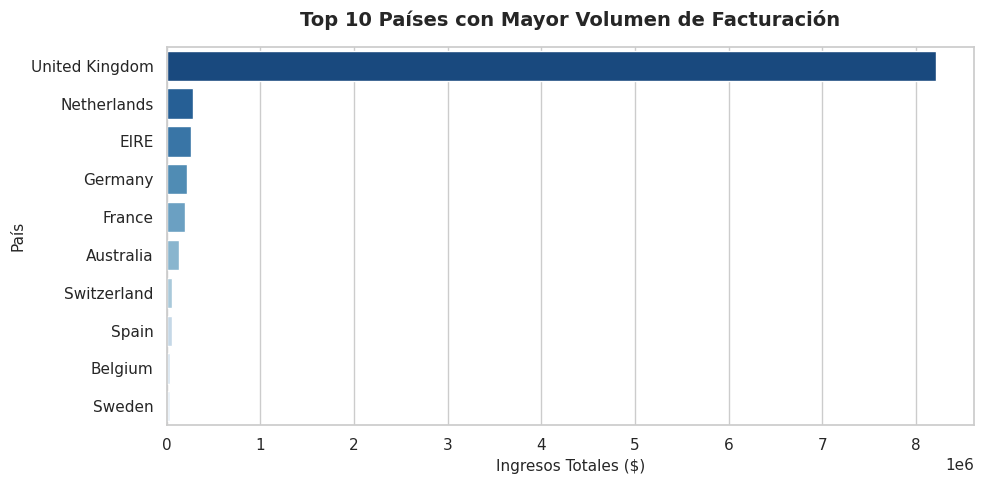

/tmp/ipykernel_1722/1186374216.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


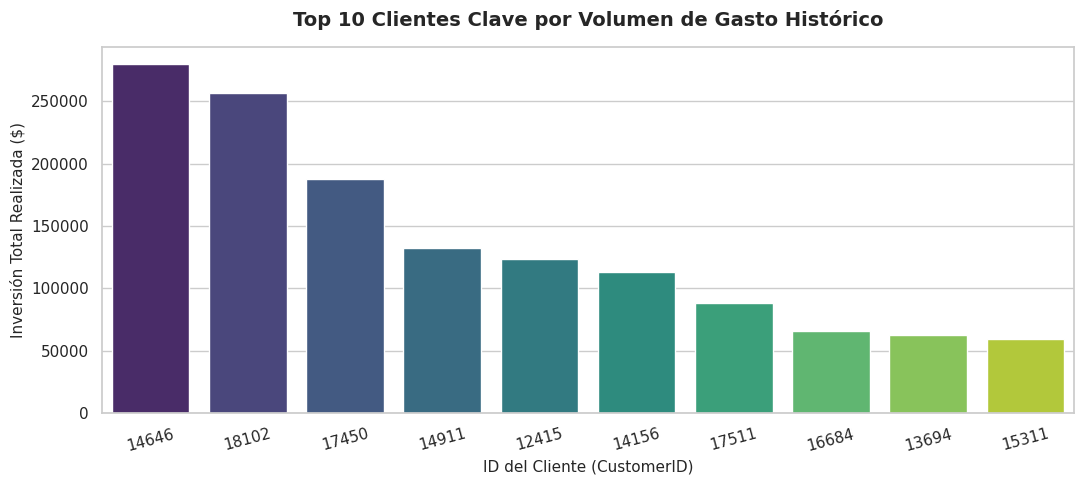

In [158]:
#code
print(" • " * 20)
print(f"""\033[1m Visualizar el modelo de negocio \033[0m""")
print(f"""\033[1m Escenario 1 facturas validas  \033[0m""")
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo corporativo limpio
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

# ==============================================================================
# GRÁFICO 1: TOP 10 PAÍSES POR INGRESOS REALES (Métrica 10)
# ==============================================================================
plt.figure(figsize=(10, 5))
sns.barplot(
    x='Total_Venta',
    y='Country',
    data=top10_paises,
    palette='Blues_r'
)
plt.title('Top 10 Países con Mayor Volumen de Facturación', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ingresos Totales ($)', fontsize=11)
plt.ylabel('País', fontsize=11)
plt.tight_layout()
plt.savefig('reporte_escenario1_geografia.png', dpi=300)
plt.show()



# ==============================================================================
# GRÁFICO 3: TOP 10 CLIENTES QUE MÁS COMPRAN VS TOTAL APORTADO (Métrica 8)
# ==============================================================================
# Convertimos el ID a string para evitar que se grafique como escala numérica continua
top10_clientes_compran['CustomerID_Str'] = top10_clientes_compran['CustomerID'].astype(int).astype(str)

plt.figure(figsize=(11, 5))
sns.barplot(
    x='CustomerID_Str',
    y='Total_Venta',
    data=top10_clientes_compran,
    palette='viridis',
    order=top10_clientes_compran['CustomerID_Str'] # Mantiene el orden descendente
)
plt.title('Top 10 Clientes Clave por Volumen de Gasto Histórico', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('ID del Cliente (CustomerID)', fontsize=11)
plt.ylabel('Inversión Total Realizada ($)', fontsize=11)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('reporte_escenario1_clientes_top.png', dpi=300)
plt.show()


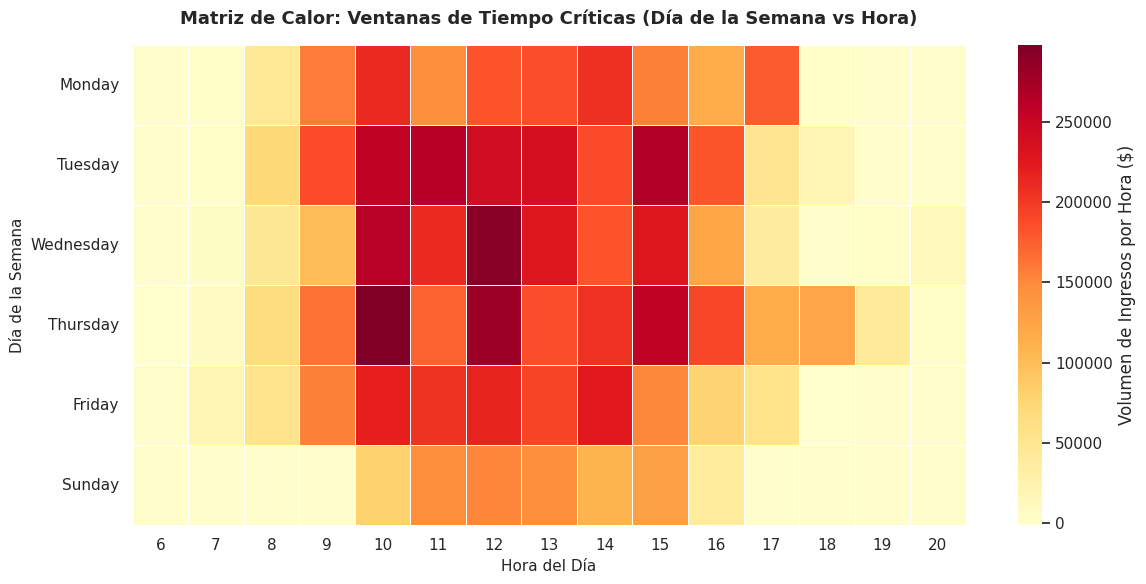

In [159]:
import matplotlib.pyplot as plt
import seaborn as sns
import logging

# 1. Silenciar las advertencias de fuentes en la consola para que no ensucien tu salida
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 2. Filtrado obligatorio del Escenario 1
df_validas = dfsql[dfsql['InvoiceNoN'].notna()].copy()
df_validas['Total_Venta'] = df_validas['Quantity'] * df_validas['UnitPrice']
df_validas['Fecha_dt'] = pd.to_datetime(df_validas['Fecha'], errors='coerce')
df_validas['Dia_Semana'] = df_validas['Fecha_dt'].dt.day_name()

# 3. Configuración estética usando fuentes por defecto del sistema
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'Arial']

# 4. Construcción de la matriz Día vs Hora
# Ajustamos los días de la semana de forma lógica para el negocio
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
matriz_dia_hora = df_validas.groupby(['Dia_Semana', 'Hora'])['Total_Venta'].sum().unstack(fill_value=0)

# Reindexamos de forma segura interceptando solo los días que sí tengan transacciones registradas
dias_presentes = [dia for dia in orden_dias if dia in matriz_dia_hora.index]
matriz_dia_hora = matriz_dia_hora.reindex(dias_presentes)

# 5. Desplegar y guardar el Mapa de Calor
plt.figure(figsize=(12, 6))
sns.heatmap(
    matriz_dia_hora,
    cmap='YlOrRd',
    cbar_kws={'label': 'Volumen de Ingresos por Hora ($)'},
    linewidths=0.5
)

plt.title('Matriz de Calor: Ventanas de Tiempo Críticas (Día de la Semana vs Hora)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Hora del Día', fontsize=11)
plt.ylabel('Día de la Semana', fontsize=11)
plt.tight_layout()

# Guardar la imagen limpia en tu carpeta de trabajo
plt.savefig('heatmap_dia_hora_limpio.png', dpi=300)
plt.show()

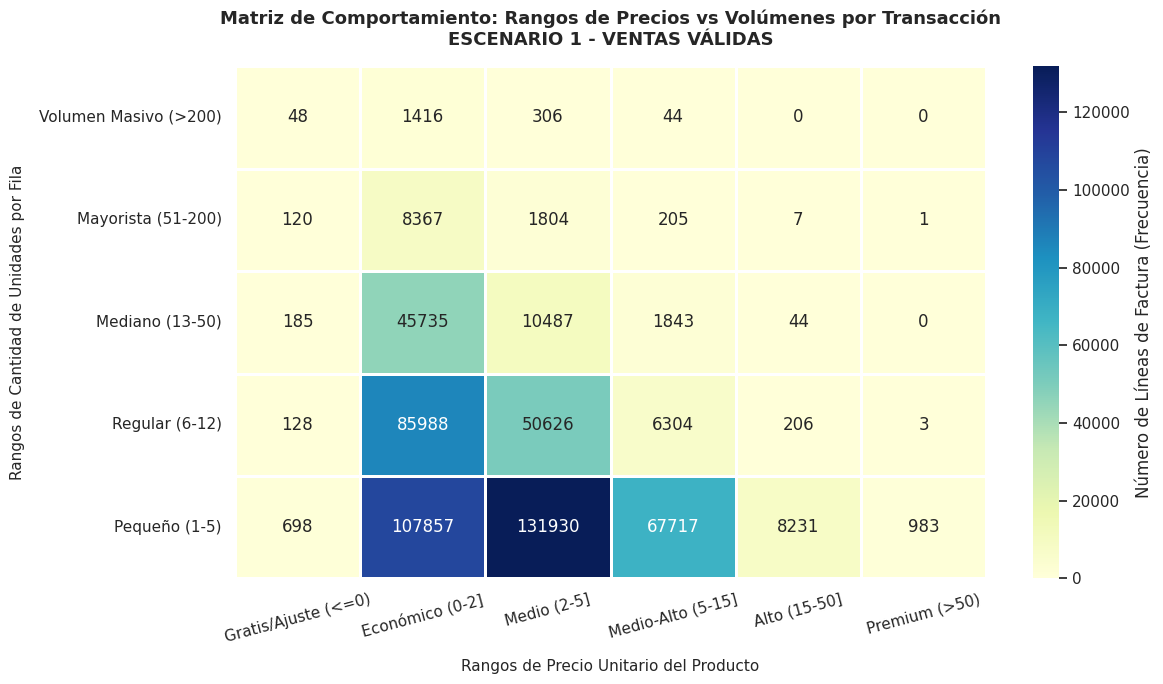

In [160]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import logging

# 1. Silenciar advertencias de fuentes en la consola
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 2. Filtrado obligatorio del Escenario 1 (Ventas Válidas)
df_validas = dfsql[dfsql['InvoiceNoN'].notna()].copy()

# 3. CREAR LOS RANGOS PARA LOS EJES
# Eje X: Rangos de Precios Unitarios (UnitPrice)
bins_precio = [-np.inf, 0, 2, 5, 15, 50, np.inf]
labels_precio = ['Gratis/Ajuste (<=0)', 'Económico (0-2]', 'Medio (2-5]', 'Medio-Alto (5-15]', 'Alto (15-50]', 'Premium (>50)']
df_validas['Rango_Precio'] = pd.cut(df_validas['UnitPrice'], bins=bins_precio, labels=labels_precio)

# Eje Y: Rangos de Cantidades de Productos por transacción (Quantity)
bins_cantidad = [0, 5, 12, 50, 200, np.inf]
labels_cantidad = ['Pequeño (1-5)', 'Regular (6-12)', 'Mediano (13-50)', 'Mayorista (51-200)', 'Volumen Masivo (>200)']
df_validas['Rango_Cantidad'] = pd.cut(df_validas['Quantity'], bins=bins_cantidad, labels=labels_cantidad)

# 4. CONSTRUIR LA MATRIZ DE INTENSIDAD (Frecuencia de transacciones / líneas de factura)
# Contamos cuántas filas caen en cada intersección de Precio y Cantidad
matriz_precio_cantidad = df_validas.groupby(['Rango_Cantidad', 'Rango_Precio'], observed=False).size().unstack(fill_value=0)

# Asegurar que el eje Y (cantidades) se lea de menor a mayor de abajo hacia arriba en el gráfico
matriz_precio_cantidad = matriz_precio_cantidad.iloc[::-1]

# ==============================================================================
# 5. DESPLEGAR EL MAPA DE CALOR (CORREGIDO)
# ==============================================================================
plt.figure(figsize=(12, 7))
sns.heatmap(
    matriz_precio_cantidad,
    cmap='YlGnBu',  # Paleta de amarillo a azul
    annot=True,     # Muestra el número exacto de registros en cada celda
    fmt="d",        # 💥 SOLUCIÓN: "d" muestra números enteros sin romper el gráfico
    cbar_kws={'label': 'Número de Líneas de Factura (Frecuencia)'},
    linewidths=0.8
)

plt.title('Matriz de Comportamiento: Rangos de Precios vs Volúmenes por Transacción\nESCENARIO 1 - VENTAS VÁLIDAS', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Rangos de Precio Unitario del Producto', fontsize=11, labelpad=10)
plt.ylabel('Rangos de Cantidad de Unidades por Fila', fontsize=11, labelpad=10)
plt.xticks(rotation=15)
plt.tight_layout()

# Guardar el gráfico en tu carpeta
plt.savefig('heatmap_precio_vs_cantidad.png', dpi=300)
plt.show()


 •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  •  • 
 Describir el modelo de negocio 
 Escenario 2 facturas no validas  


/tmp/ipykernel_1722/2189731422.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


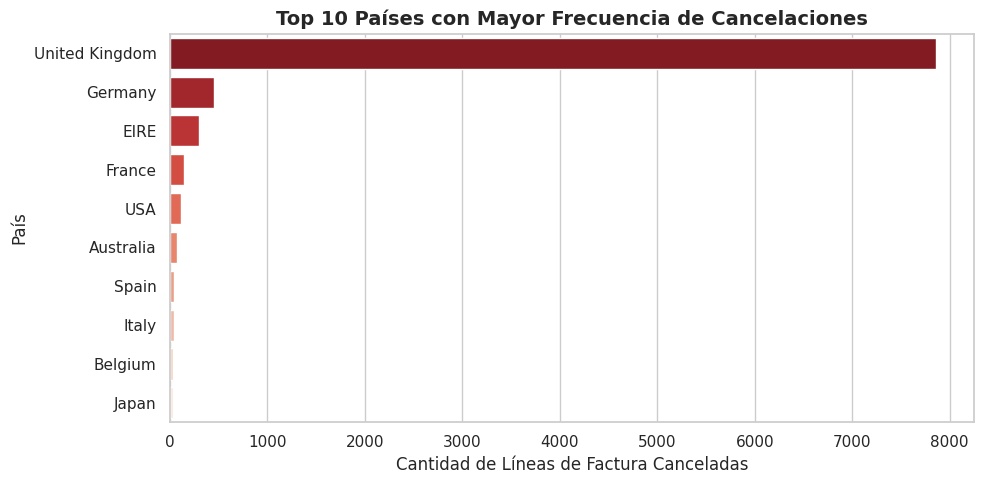

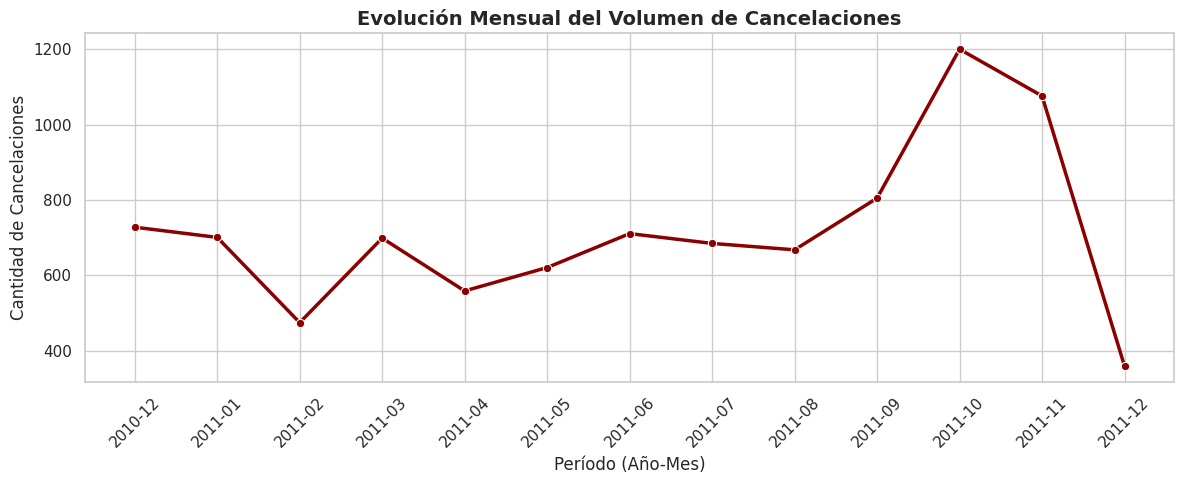

In [161]:
print(" • " * 20)
print(f"""\033[1m Describir el modelo de negocio \033[0m""")
print(f"""\033[1m Escenario 2 facturas no validas  \033[0m""")
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética global
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ------------------------------------------------------------------------------
# GRÁFICO 1: Top 10 Países que más cancelan (Gráfico de Barras Horizontal)
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.barplot(
    x='Frecuencia',
    y='Country',
    data=top10_paises_canc,
    palette='Reds_r'
)
plt.title('Top 10 Países con Mayor Frecuencia de Cancelaciones', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Líneas de Factura Canceladas', fontsize=12)
plt.ylabel('País', fontsize=12)
plt.tight_layout()
plt.savefig('top10_paises_cancelados.png', dpi=300)
plt.show()

# ------------------------------------------------------------------------------
# GRÁFICO 2: Comportamiento Temporal por Mes (Gráfico de Líneas/Barras)
# ------------------------------------------------------------------------------
plt.figure(figsize=(12, 5))
sns.lineplot(
    x='AñoMes',
    y='Frecuencia',
    data=df_canceladas['AñoMes'].value_counts().sort_index().reset_index().rename(columns={'count': 'Frecuencia'}),
    marker='o',
    color='darkred',
    linewidth=2.5
)
plt.title('Evolución Mensual del Volumen de Cancelaciones', fontsize=14, fontweight='bold')
plt.xlabel('Período (Año-Mes)', fontsize=12)
plt.ylabel('Cantidad de Cancelaciones', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('evolucion_mensual_cancelaciones.png', dpi=300)
plt.show()


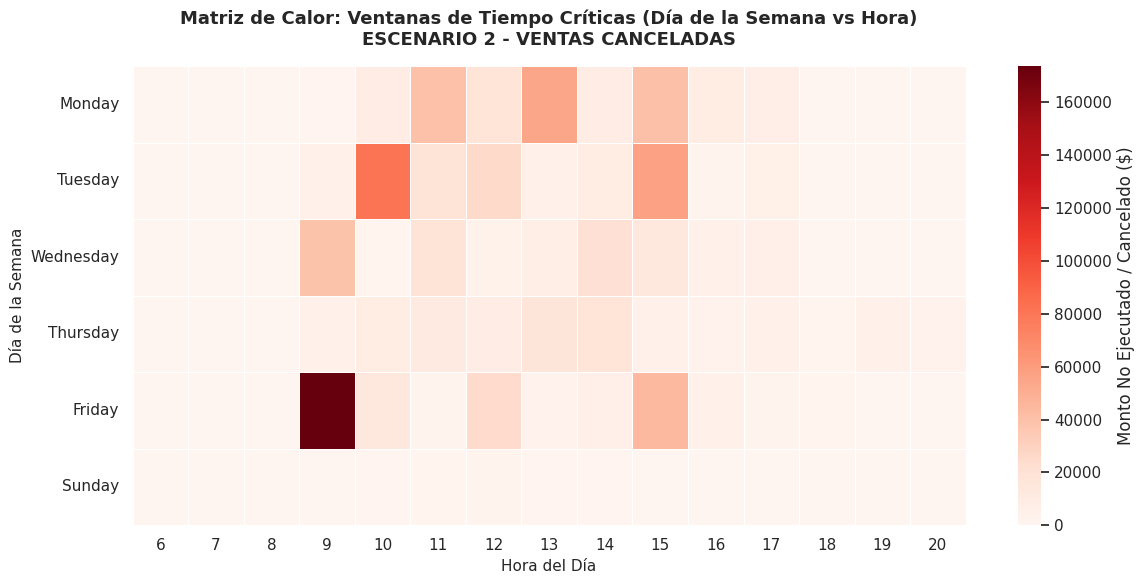

In [162]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import logging

# 1. Silenciar advertencias de fuentes en la consola
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 2. FILTRADO INICIAL: Seleccionar solo registros del Escenario 2
df_canceladas = dfsql[dfsql['InvoiceNo_C'] == 1].copy()

# Calcular el monto que no se ejecutó usando el valor absoluto de la cantidad
df_canceladas['Quantity_Abs'] = df_canceladas['Quantity'].abs()
df_canceladas['Monto_No_Ejecutado'] = df_canceladas['Quantity_Abs'] * df_canceladas['UnitPrice']

# Asegurar el formato de fecha para extraer el día de la semana
df_canceladas['Fecha_dt'] = pd.to_datetime(df_canceladas['Fecha'], errors='coerce')
df_canceladas['Dia_Semana'] = df_canceladas['Fecha_dt'].dt.day_name()

# 3. Configuración estética segura para las fuentes
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'Arial']

# 4. Construcción de la matriz Día vs Hora para Cancelaciones
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
matriz_canc_dia_hora = df_canceladas.groupby(['Dia_Semana', 'Hora'])['Monto_No_Ejecutado'].sum().unstack(fill_value=0)

# Reindexar de forma segura interceptando solo los días presentes con datos
dias_presentes = [dia for dia in orden_dias if dia in matriz_canc_dia_hora.index]
matriz_canc_dia_hora = matriz_canc_dia_hora.reindex(dias_presentes)

# 5. Desplegar y guardar el Mapa de Calor (Usamos una paleta de rojos/púrpuras para denotar "pérdida/alerta")
plt.figure(figsize=(12, 6))
sns.heatmap(
    matriz_canc_dia_hora,
    cmap='Reds', # Paleta de colores degradados en rojo para identificar mermas
    cbar_kws={'label': 'Monto No Ejecutado / Cancelado ($)'},
    linewidths=0.5
)

plt.title('Matriz de Calor: Ventanas de Tiempo Críticas (Día de la Semana vs Hora)\nESCENARIO 2 - VENTAS CANCELADAS', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Hora del Día', fontsize=11)
plt.ylabel('Día de la Semana', fontsize=11)
plt.tight_layout()

# Guardar el archivo independiente para tu reporte
plt.savefig('heatmap_escenario2_canceladas.png', dpi=300)
plt.show()

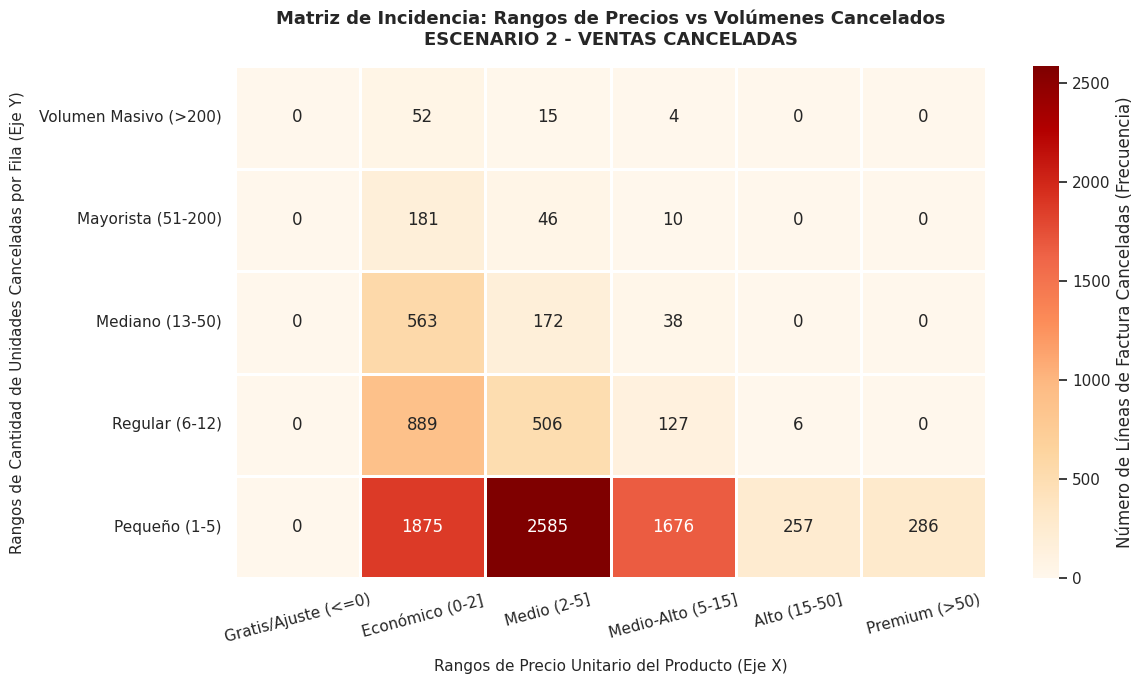

In [163]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import logging

# 1. Silenciar advertencias de fuentes en la consola
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 2. Filtrado obligatorio del Escenario 2 (Ventas Canceladas)
df_canceladas = dfsql[dfsql['InvoiceNo_C'] == 1].copy()

# 💥 Crucial para cancelaciones: Pasar cantidades a valor absoluto positivo
df_canceladas['Quantity_Abs'] = df_canceladas['Quantity'].abs()

# 3. CREAR LOS RANGOS PARA LOS EJES (Mantenemos los mismos del Escenario 1 para poder comparar)
# Eje X: Rangos de Precios Unitarios
bins_precio = [-np.inf, 0, 2, 5, 15, 50, np.inf]
labels_precio = ['Gratis/Ajuste (<=0)', 'Económico (0-2]', 'Medio (2-5]', 'Medio-Alto (5-15]', 'Alto (15-50]', 'Premium (>50)']
df_canceladas['Rango_Precio'] = pd.cut(df_canceladas['UnitPrice'], bins=bins_precio, labels=labels_precio)

# Eje Y: Rangos de Cantidades Absolutas Canceladas por fila
bins_cantidad = [0, 5, 12, 50, 200, np.inf]
labels_cantidad = ['Pequeño (1-5)', 'Regular (6-12)', 'Mediano (13-50)', 'Mayorista (51-200)', 'Volumen Masivo (>200)']
df_canceladas['Rango_Cantidad'] = pd.cut(df_canceladas['Quantity_Abs'], bins=bins_cantidad, labels=labels_cantidad)

# 4. CONSTRUIR LA MATRIZ DE INTENSIDAD (Frecuencia de líneas de facturas canceladas)
matriz_canc_precio_cantidad = df_canceladas.groupby(['Rango_Cantidad', 'Rango_Precio'], observed=False).size().unstack(fill_value=0)

# Asegurar que el eje Y (cantidades) se lea de menor a mayor de abajo hacia arriba
matriz_canc_precio_cantidad = matriz_canc_precio_cantidad.iloc[::-1]

# 5. DESPLEGAR EL MAPA DE CALOR (Usamos tonos Rojos/Naranjas para denotar cancelaciones)
plt.figure(figsize=(12, 7))
sns.heatmap(
    matriz_canc_precio_cantidad,
    cmap='OrRd',     # Paleta de naranja a rojo, ideal para alertas o pérdidas
    annot=True,     # Muestra el número de transacciones en cada celda
    fmt="d",        # ✅ Formato corregido para evitar el ValueError
    cbar_kws={'label': 'Número de Líneas de Factura Canceladas (Frecuencia)'},
    linewidths=0.8
)

plt.title('Matriz de Incidencia: Rangos de Precios vs Volúmenes Cancelados\nESCENARIO 2 - VENTAS CANCELADAS', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Rangos de Precio Unitario del Producto (Eje X)', fontsize=11, labelpad=10)
plt.ylabel('Rangos de Cantidad de Unidades Canceladas por Fila (Eje Y)', fontsize=11, labelpad=10)
plt.xticks(rotation=15)
plt.tight_layout()

# Guardar el gráfico del Escenario 2
plt.savefig('heatmap_precio_vs_cantidad_canceladas.png', dpi=300)
plt.show()
